100%|██████████| 5000/5000 [00:01<00:00, 4882.41it/s]


Total images: 5000
Corrupt images: 0
Unique formats: {'JPEG'}
Most common size: [((178, 218), 5000)]


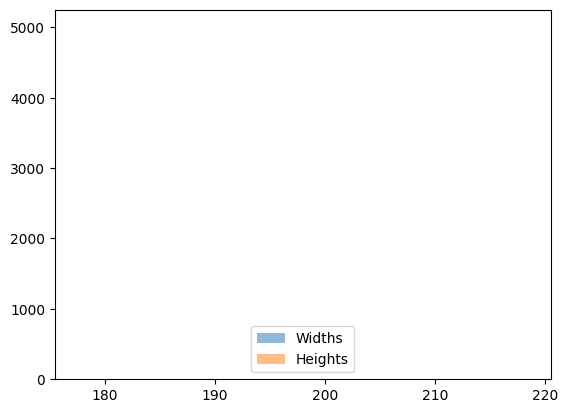

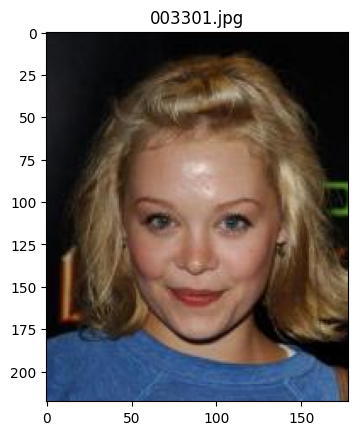

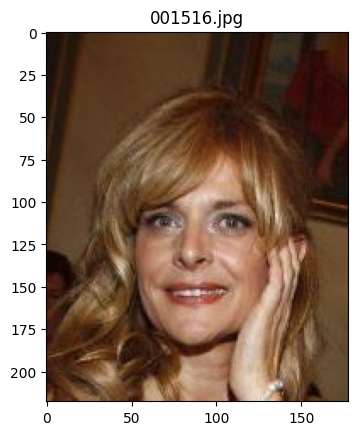

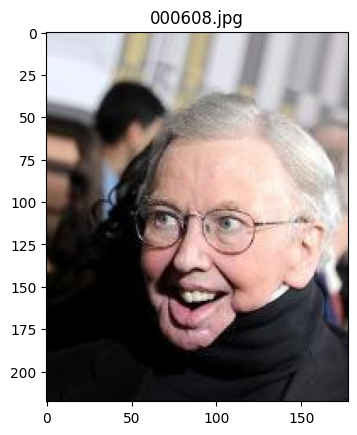

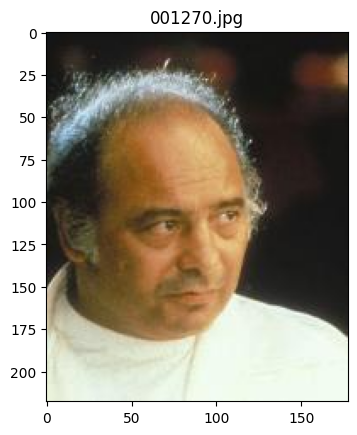

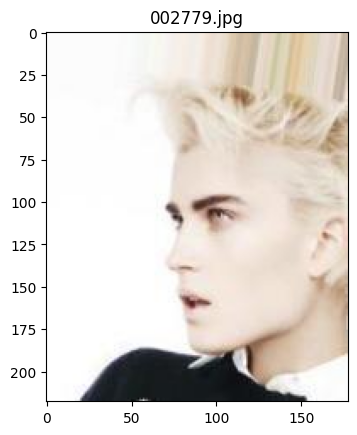

In [3]:
import os
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

DATASET_PATH = "/Users/dhruval/Documents/GAN-ish-idek/dataset/Real Images"

sizes = []
formats = []
corrupt_files = []

for filename in tqdm(os.listdir(DATASET_PATH)):
    file_path = os.path.join(DATASET_PATH, filename)
    try:
        with Image.open(file_path) as img:
            formats.append(img.format)
            sizes.append(img.size)  # (width, height)
    except Exception as e:
        corrupt_files.append(filename)

print(f"Total images: {len(sizes) + len(corrupt_files)}")
print(f"Corrupt images: {len(corrupt_files)}")
print(f"Unique formats: {set(formats)}")
print("Most common size:", Counter(sizes).most_common(5))

widths, heights = zip(*sizes)
plt.hist(widths, bins=20, alpha=0.5, label='Widths')
plt.hist(heights, bins=20, alpha=0.5, label='Heights')
plt.legend()
plt.show()

sample_files = os.listdir(DATASET_PATH)[:5]
for f in sample_files:
    img = Image.open(os.path.join(DATASET_PATH, f))
    plt.imshow(img)
    plt.title(f)
    plt.show()


In [4]:
import os
from PIL import Image

input_folder = "/Users/dhruval/Documents/GAN-ish-idek/dataset/Real Images"
output_folder = "/Users/dhruval/Documents/GAN-ish-idek/dataset/resized"

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

count = 0
for filename in os.listdir(input_folder):
    if filename.lower().endswith((".png", ".jpg", ".jpeg")):
        img_path = os.path.join(input_folder, filename)
        try:
            img = Image.open(img_path).convert("RGB")
            img_resized = img.resize((128, 128), Image.LANCZOS)  # Resize directly
            img_resized.save(os.path.join(output_folder, filename))
            count += 1
        except Exception as e:
            print(f"Error processing {filename}: {e}")

print(f"Done! Resized {count} images to 128×128.")


✅ Done! Resized 5000 images to 128×128.
